# Catatan Tanya-Jawab & Eksplorasi Teoretis: Optimasi Parameter GP
**Rujukan Tunggal**: Rasmussen, C. E., \& Williams, C. K. (2006). *Gaussian Processes for Machine Learning*. MIT Press, Cambridge, MA.  
**Fokus**: Chapter 5 (*Model Selection and Adaptation of Hyperparameters*)

---

## ❓ Pertanyaan 1:
> **"Apakah benar untuk mempelajari optimasi parameter GP berdasarkan buku Rasmussen ini, maka saya harus membaca Chapter 5? Jika iya, tolong jelaskan secara singkat atau overviewnya apa yang dibahas pada setiap subbab chapter 5 ini."**

### 💡 Jawaban & Konfirmasi:
**YA, BENAR SEKALI.**  
Dalam buku teks *Gaussian Processes for Machine Learning* (Rasmussen \& Williams, 2006), seluruh pembahasan mengenai bagaimana cara memilih, mengadaptasi, dan mengoptimasi parameter (yang secara formal disebut **hyperparameter**) dibahas secara mendalam dan tuntas pada **Chapter 5: Model Selection and Adaptation of Hyperparameters** (hlm. 105–128).

---

### 🗺️ Pemetaan Lengkap Subbab Chapter 5 Rasmussen \& Williams (2006)

1. **Subbab 5.1: The Model Selection Problem (hlm. 105–108)**
   * Menjelaskan bahwa parameter pada GP (seperti $l, \sigma_f^2, \sigma_n^2$) adalah **hyperparameter** dari proses stokastik, bukan bobot regresi linier biasa.
   * Merumuskan **Hierarki Inferensi Bayesian Tiga Tingkat (3-Level Bayesian Inference Hierarchy)**:
     * **Level 1 (Inferensi Fungsi Laten $\mathbf{f}$)**: $p(\mathbf{f} \mid \mathbf{y}, X, \boldsymbol{\theta})$ dengan $\boldsymbol{\theta}$ tetap.
     * **Level 2 (Adaptasi Hyperparameter $\boldsymbol{\theta}$)**: $p(\boldsymbol{\theta} \mid \mathbf{y}, X) \propto p(\mathbf{y} \mid X, \boldsymbol{\theta}) p(\boldsymbol{\theta})$ (hlm. 109, Persamaan 5.2).
     * **Level 3 (Perbandingan Model $\mathcal{H}_i$)**: $p(\mathcal{H}_i \mid \mathbf{y}, X)$ (hlm. 109, Persamaan 5.3).
   * Menjelaskan bahaya optimasi tanpa marginalisasi yang memicu *severe overfitting* ($l \to 0, \sigma_n \to 0$).

2. **Subbab 5.2: The Bayesian Framework (hlm. 108–111)**
   * Membahas integrasi Bayesian penuh (*Full Bayesian Treatment*) vs estimasi titik (*Point Estimates*).
   * Membandingkan 3 pendekatan: **Type II Maximum Likelihood (ML-II) / Empirical Bayes**, **Maximum A Posteriori (MAP)** (hlm. 109), dan **Markov Chain Monte Carlo (MCMC)**.

3. **Subbab 5.3: Cross-Validation (hlm. 111–112)**
   * Menjelaskan metode validasi silang (*Leave-One-Out Cross-Validation* / LOO-CV) untuk Squared Error (Persamaan 5.5, hlm. 111) dan Log Predictive Probability (Persamaan 5.6, hlm. 111).

4. **Subbab 5.4: Model Selection for GP Regression (hlm. 112–124) [SUBBAB INTI]**
   * **5.4.1 Marginal Likelihood Computation and its Derivatives (hlm. 112–116)**:
     * Penurunan analitik Log Marginal Likelihood (LML, Persamaan 5.7 & 5.8, hlm. 112–113) & prinsip Occam's Razor otomatis.
     * Penurunan Gradien Analitik (Persamaan 5.9, hlm. 114): $\frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left((\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1})\frac{\partial K_y}{\partial \theta_j}\right)$.
     * Implementasi komputasi numerik stabil via Dekomposisi Cholesky (Algoritma 5.1, hlm. 114).
     * Transformasi ruang parameter log-space ($\tilde{\theta}_j = \log \theta_j$).
   * **5.4.2 Cross-validation (hlm. 116–118)**:
     * Formulasi analitik LOO prediktif GP: $\mu_i$ (Persamaan 5.12, hlm. 117) dan $\sigma_i^2$ (Persamaan 5.13, hlm. 117).
     * LOO-CV Log Predictive Probability (Persamaan 5.11, hlm. 116).
     * Turunan analitik LOO-SE (Persamaan 5.14, hlm. 117) dan LOO-NLPL (Persamaan 5.15, hlm. 118).
   * **5.4.3 Examples and Discussion (hlm. 118–124)**: Analisis permukaan LML non-konveks, fenomena multimodalitas (lokal optima), dan strategi *Random Restarts*.

5. **Subbab 5.5: Model Selection for GP Classification (hlm. 124–128)**
   * Membahas pemilihan model pada kasus klasifikasi biner/multikelas menggunakan aproksimasi analitik (Laplace Approximation atau Expectation Propagation - EP) karena likelihood non-Gaussian.


---

## ❓ Pertanyaan 2:
> **"Apakah fungsi-fungsi yang kamu tulis di setiap section tersebut merupakan fungsi objektif?"**

### 💡 Jawaban & Penjelasan:
**YA, SEMUANYA ADALAH FUNGSI OBJEKTIF (*Objective Functions*).**

Dalam konteks matematika optimasi dan pembelajaran mesin (*machine learning*), **fungsi objektif** adalah fungsi matematis yang nilainya ingin kita **maksimumkan** (*maximization*) atau **minimumkan** (*minimization*) terhadap hyperparameter $\boldsymbol{\theta} = [l, \sigma_f, \sigma_n]^T$ untuk menemukan konfigurasi model terbaik $\boldsymbol{\theta}^*$.

Berikut adalah rincian peran, formulasi matematika, dan tujuan dari masing-masing fungsi objektif pada dokumen bimbingan:

---

### 1. Section 1: Marginal Likelihood / Evidence (ML-II)
* **Tipe Optimasi**: Maksimasi $\mathcal{L}(\boldsymbol{\theta})$ atau Minimasi $\operatorname{NLML}(\boldsymbol{\theta})$.
* **Formulasi Matematika**:
  $$\mathcal{L}(\boldsymbol{\theta}) = \log p(\mathbf{y} \mid X, \boldsymbol{\theta}) = -\frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y} - \frac{1}{2}\log\det(K_y) - \frac{N}{2}\log(2\pi)$$
  $$\operatorname{NLML}(\boldsymbol{\theta}) = -\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y} + \frac{1}{2}\log\det(K_y) + \frac{N}{2}\log(2\pi)$$
* **Tujuan**: Mencari hyperparameter yang memaksimumkan probabilitas data training teramati setelah mengintegralkan seluruh kemungkinan fungsi laten $\mathbf{f}$ (Metode standar utama dalam Gaussian Process).

---

### 2. Section 2: Maximum A Posteriori (MAP)
* **Tipe Optimasi**: Maksimasi $\mathcal{L}_{\text{MAP}}(\boldsymbol{\theta})$.
* **Formulasi Matematika**:
  $$\mathcal{L}_{\text{MAP}}(\boldsymbol{\theta}) = \log p(\mathbf{y} \mid X, \boldsymbol{\theta}) + \log p(\boldsymbol{\theta}) = -\frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y} - \frac{1}{2}\log\det(K_y) + \log p(\boldsymbol{\theta}) + \text{konstanta}$$
* **Tujuan**: Memadukan bukti data (*Marginal Likelihood*) dengan distribusi prior hyperparameter $p(\boldsymbol{\theta})$ untuk mencegah estimasi nilai parameter yang ekstrem atau tidak realistis.

---

### 3. Section 3: Leave-One-Out Cross-Validation: Squared Error (LOO-SE)
* **Tipe Optimasi**: Minimasi $L_{\text{LOO-SE}}(\boldsymbol{\theta})$.
* **Formulasi Matematika**:
  $$L_{\text{LOO-SE}}(\boldsymbol{\theta}) = \sum_{i=1}^N (y_i - \mu_{-i})^2 = \sum_{i=1}^N \left( \frac{[K_y^{-1}\mathbf{y}]_i}{[K_y^{-1}]_{ii}} \right)^2$$
* **Tujuan**: Meminimalkan akumulasi galat kuadratik prediksi *out-of-sample* dari setiap titik data saat dikeluarkan satu per satu.

---

### 4. Section 4: LOO-CV: Negative Log Pseudo-Likelihood (LOO-NLPL)
* **Tipe Optimasi**: Minimasi $L_{\text{LOO-NLPL}}(\boldsymbol{\theta})$.
* **Formulasi Matematika**:
  $$L_{\text{LOO-NLPL}}(\boldsymbol{\theta}) = -\sum_{i=1}^N \log p(y_i \mid X, \mathbf{y}_{-i}, \boldsymbol{\theta}) = \frac{1}{2} \sum_{i=1}^N \left( -\log [K_y^{-1}]_{ii} + \frac{([K_y^{-1}\mathbf{y}]_i)^2}{[K_y^{-1}]_{ii}} + \log(2\pi) \right)$$
* **Tujuan**: Meminimalkan ketidakpastian negatif prediksi probabilistik *out-of-sample* dengan memperhitungkan mean prediktif $\mu_{-i}$ sekaligus variansi prediktif $\sigma_{-i}^2$.


---

## ❓ Pertanyaan 3 & 4:
> **"Untuk masing-masing fungsi objektif tersebut, apa metode optimasi yang bisa atau sering digunakan? Bagaimana cara mengoptimasinya?"**

### 💡 Jawaban Komprehensif: Pemetaan Metode Optimasi per Fungsi Objektif

Setiap fungsi objektif memiliki karakteristik kelengkungan, kehalusan permukaan, dan ketersediaan turunan analitik yang berbeda. Berdasarkan **Rasmussen & Williams (2006, Chapter 5)** dan implementasi standar dalam pustaka modern GP (GPML, GPyTorch, GPflow, scikit-learn), berikut adalah rincian metode optimasi yang digunakan untuk masing-masing fungsi objektif:

---

### 🎯 1. Untuk Marginal Likelihood (ML-II / Section 1)
* **Karakteristik Fungsi**:
  * Bersifat mulus (*smooth*), terdiferensialkan kontinu terhadap semua hyperparameter.
  * Memiliki gradien analitik eksak $\mathcal{O}(N^2)$ via Dekomposisi Cholesky (Persamaan 5.9).
  * Permukaannya **non-konveks** (*multimodal*, memiliki kemungkinan beberapa lokal optima).
* **Metode yang Paling Sering Digunakan**:
  1. **Non-linear Conjugate Gradient (CG) (Polak-Ribière / Fletcher-Reeves)**:
     * **Status**: *Metode default bawaan toolbox resmi GPML Matlab karya Carl Edward Rasmussen (`minimize.m`)*.
     * Menggunakan arah pencarian konjugat dengan *line search* kondisi Wolfe-Powell. Sangat efisien dalam penggunaan memori untuk dimensi hyperparameter sedang hingga tinggi.
  2. **Quasi-Newton / L-BFGS-B (Limited-memory BFGS with Bounds)**:
     * **Status**: *Metode paling populer dan standar dalam pustaka Python modern (scipy, scikit-learn, GPflow)*.
     * Mengaproksimasi matriks kelengkungan Hessian terbalik ($H^{-1}$) secara efisien dengan laju konvergensi superlinear, serta mendukung pembatasan batas nilai (*box bounds*).
  3. **Multi-Restart L-BFGS-B / CG (Pencegah Lokal Optima)**:
     * Menjalankan optimizer dari 5–20 titik inisialisasi awal acak ($\tilde{\boldsymbol{\theta}}_0^{(s)}$) di ruang pencarian logaritmik, lalu memilih hasil dengan nilai LML tertinggi.
  4. **Stochastic Gradient Descent (Adam / SGD)**:
     * Digunakan khusus untuk *Sparse Gaussian Process* (Inducing Points) atau *Deep Gaussian Process* (DGP) dengan data berskala besar ($N > 10^4$).

---

### 🎯 2. Untuk Maximum A Posteriori (MAP / Section 2)
* **Karakteristik Fungsi**:
  * Identik dengan Marginal Likelihood ditambah suku log-prior $\log p(\boldsymbol{\theta})$ (seperti *Log-Normal prior*, *Gamma prior*, atau *Gaussian prior*).
  * Menghasilkan penalti regularisasi yang menghaluskan permukaan objektif dan mencegah *over-fitting* atau nilai hyperparameter yang menyimpang ke batas ekstrem ($l \to 0$ atau $\sigma_n \to 0$).
* **Metode yang Paling Sering Digunakan**:
  1. **L-BFGS-B & Conjugate Gradient (CG) Bergradien**:
     * Gradien analitik langsung ditambahkan: $\nabla_{\boldsymbol{\theta}} \mathcal{L}_{\text{MAP}} = \nabla_{\boldsymbol{\theta}} \mathcal{L}_{\text{ML}} + \nabla_{\boldsymbol{\theta}} \log p(\boldsymbol{\theta})$.
     * Bekerja sangat cepat dan stabil karena penalti prior membantu mempercepat konvergensi.
  2. **Hamiltonian Monte Carlo (HMC) / No-U-Turn Sampler (NUTS)**:
     * **Status**: *Metode inferensi Bayesian penuh (Full Bayesian Sampling)*.
     * Karena adanya prior eksplisit $p(\boldsymbol{\theta})$, algoritma HMC/NUTS mensimulasikan dinamika fisik Hamiltonian menggunakan vektor gradien untuk mengambil ribuan sampel dari distribusi posterior hyperparameter $p(\boldsymbol{\theta} \mid \mathbf{y}, X)$, alih-alih hanya mencari satu titik puncak mode.

---

### 🎯 3. Untuk LOO Cross-Validation: Squared Error (LOO-SE / Section 3)
* **Karakteristik Fungsi**:
  * Berfokus murni pada akurasi titik prediksi (*point accuracy* / Mean Squared Error).
  * Memiliki turunan analitik (Persamaan 5.14 Rasmussen), namun permukaannya cenderung **kurang mulus dan memiliki banyak lekukan/lembah tajam** dibandingkan Marginal Likelihood.
* **Metode yang Digunakan**:
  1. **L-BFGS-B / Gradient Descent Bergradien**:
     * Menggunakan turunan parsial eksak LOO-SE (Rasmussen Persamaan 5.14):
       $$\frac{\partial L_{\text{LOO-SE}}}{\partial \theta_j} = 2 \sum_{i=1}^N \frac{\alpha_i}{[K_y^{-1}]_{ii}} \left( \frac{[K_y^{-1}\frac{\partial K_y}{\partial \theta_j}\boldsymbol{\alpha}]_i}{[K_y^{-1}]_{ii}} - \frac{\alpha_i [K_y^{-1}\frac{\partial K_y}{\partial \theta_j} K_y^{-1}]_{ii}}{([K_y^{-1}]_{ii})^2} \right)$$
  2. **Metode Bebas-Gradien (*Derivative-Free / Direct Search*)**:
     * **Nelder-Mead Simplex Algorithm** atau **Powell Method**: Sering menjadi pilihan praktis karena implementasi turunan analitik LOO-SE jauh lebih rumit dibandingkan turunan Marginal Likelihood, sementara evaluasi nilai $L_{\text{LOO-SE}}$ dapat dihitung cepat dalam $\mathcal{O}(N^3)$ via Cholesky.
  3. **Grid Search / Bayesian Optimization**:
     * Efektif jika jumlah hyperparameter sedikit ($P \le 3$, misal hanya $l$ dan $\sigma_n$).

---

### 🎯 4. Untuk LOO-CV: Negative Log Pseudo-Likelihood (LOO-NLPL / Section 4)
* **Karakteristik Fungsi**:
  * Mengukur kualitas prediksi probabilistik penuh (memperhitungkan mean prediktif $\mu_{-i}$ sekaligus ketidakpastian variansi $\sigma_{-i}^2$).
  * Memiliki permukaan yang **lebih mulus dan lebih stabil daripada LOO-SE** berkat adanya suku penalti variansi $-\log [K_y^{-1}]_{ii}$.
* **Metode yang Digunakan**:
  1. **Conjugate Gradient (CG) / L-BFGS-B**:
     * Menggunakan turunan parsial eksak LOO-NLPL (Rasmussen Persamaan 5.15):
       $$\frac{\partial L_{\text{LOO-NLPL}}}{\partial \theta_j} = \frac{1}{2} \sum_{i=1}^N \left[ \frac{1}{[K_y^{-1}]_{ii}} - \frac{\alpha_i^2}{([K_y^{-1}]_{ii})^2} \right] \left[ K_y^{-1} \frac{\partial K_y}{\partial \theta_j} K_y^{-1} \right]_{ii} + \sum_{i=1}^N \frac{\alpha_i}{[K_y^{-1}]_{ii}} \left[ K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha} \right]_i$$
  2. **Nelder-Mead Simplex / Direct Search**:
     * Alternatif numerik cepat tanpa perlu menurunkan dan mengevaluasi matriks turunan yang kompleks.
  3. **Multistart Local Search**:
     * Menjalankan pencarian lokal dari beberapa inisialisasi untuk mengatasi minima lokal.

---

### 📊 Rangkuman Perbandingan Metode Optimasi per Fungsi Objektif

| Fungsi Objektif | Sifat Permukaan | Ketersediaan Gradien Analitik | Metode Optimasi Utama | Metode Alternatif |
|---|---|---|---|---|
| **1. Marginal Likelihood (ML-II)** | Sangat Mulus, Non-Konveks | Eksak & Sangat Efisien (Persamaan 5.9) | **L-BFGS-B**, **Conjugate Gradient (CG)**, **Multi-Restart** | Adam / SGD (Skala Besar) |
| **2. Maximum A Posteriori (MAP)** | Lebih Mulus (Terdampingi Prior) | Eksak ($\nabla \mathcal{L}_{\text{ML}} + \nabla \log p$) | **L-BFGS-B**, **Conjugate Gradient (CG)** | **HMC / NUTS** (Full Bayesian Sampling) |
| **3. LOO-CV: Squared Error (LOO-SE)** | Kurang Mulus, Banyak Lembah Tajam | Eksak (Persamaan 5.14, Rumit) | **Nelder-Mead**, **L-BFGS-B** | Grid Search / Bayesian Opt |
| **4. LOO-CV: Pseudo-Likelihood (NLPL)** | Cukup Mulus (Probabilistik) | Eksak (Persamaan 5.15) | **L-BFGS-B**, **Conjugate Gradient (CG)** | Nelder-Mead / Powell |


---
## 🧪 Eksperimen Komputasi: Uji Performa Berbagai Optimizer pada Fungsi Objektif
Di bawah ini kita menguji secara langsung kinerja algoritma optimizer (**L-BFGS-B**, **Conjugate Gradient**, dan **Nelder-Mead**) pada fungsi objektif **Marginal Likelihood**, serta membandingkannya dengan fungsi objektif **LOO-CV**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# 1. Pembangkitan Data Observasi Sintetis (Rasmussen Style)
N = 25
X_train = np.sort(np.random.uniform(-4, 4, N))[:, None]
true_func = lambda x: np.sin(1.5 * x) + 0.5 * np.cos(3.0 * x)
sigma_n_true = 0.20
y_train = true_func(X_train).ravel() + np.random.normal(0, sigma_n_true, N)

X_test = np.linspace(-5, 5, 250)[:, None]
y_true_test = true_func(X_test).ravel()

def se_kernel(X1, X2, l, sigma_f):
    r2 = np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=-1)
    return (sigma_f**2) * np.exp(-0.5 * r2 / (l**2))

print(f"Dataset berhasil dibangkitkan: N = {N} sampel.")


Dataset berhasil dibangkitkan: N = 25 sampel.


In [2]:
# 2. Implementasi Fungsi Objektif dan Gradien Analitik

def nlml_and_grad(log_theta, X, y):
    l = np.exp(log_theta[0])
    sigma_f = np.exp(log_theta[1])
    sigma_n = np.exp(log_theta[2])
    N = len(y)
    
    K = se_kernel(X, X, l, sigma_f)
    Ky = K + (sigma_n**2 + 1e-7) * np.eye(N)
    
    L = np.linalg.cholesky(Ky)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    
    # NLML
    nlml = 0.5 * np.dot(y, alpha) + np.sum(np.log(np.diag(L))) + 0.5 * N * np.log(2 * np.pi)
    
    # Gradien via Cholesky invers
    Ky_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    W = np.outer(alpha, alpha) - Ky_inv
    
    r2 = np.sum((X[:, None, :] - X[None, :, :])**2, axis=-1)
    dK_dl = K * (r2 / (l**3))
    dK_dsf = 2.0 * sigma_f * np.exp(-0.5 * r2 / (l**2))
    dKy_sn = 2.0 * sigma_n * np.eye(N)
    
    grad_l = -0.5 * np.sum(W * dK_dl) * l
    grad_sf = -0.5 * np.sum(W * dK_dsf) * sigma_f
    grad_sn = -0.5 * np.sum(W * dKy_sn) * sigma_n
    
    return nlml, np.array([grad_l, grad_sf, grad_sn])

def map_and_grad(log_theta, X, y):
    # MAP dengan Gaussian Prior pada log(l) ~ N(0, 1), log(sf) ~ N(0, 1), log(sn) ~ N(-1.5, 1)
    nlml, grad_nlml = nlml_and_grad(log_theta, X, y)
    
    prior_mean = np.array([0.0, 0.0, -1.5])
    prior_var = 1.0
    
    log_prior = -0.5 * np.sum((log_theta - prior_mean)**2 / prior_var)
    grad_log_prior = -(log_theta - prior_mean) / prior_var
    
    n_map = nlml - log_prior
    grad_n_map = grad_nlml - grad_log_prior
    return n_map, grad_n_map

def loo_se_objective(log_theta, X, y):
    l = np.exp(log_theta[0])
    sigma_f = np.exp(log_theta[1])
    sigma_n = np.exp(log_theta[2])
    N = len(y)
    
    K = se_kernel(X, X, l, sigma_f)
    Ky = K + (sigma_n**2 + 1e-7) * np.eye(N)
    try:
        L = np.linalg.cholesky(Ky)
        Ky_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        loo_res = alpha / np.diag(Ky_inv)
        return np.sum(loo_res**2)
    except np.linalg.LinAlgError:
        return 1e10

def loo_nlpl_objective(log_theta, X, y):
    l = np.exp(log_theta[0])
    sigma_f = np.exp(log_theta[1])
    sigma_n = np.exp(log_theta[2])
    N = len(y)
    
    K = se_kernel(X, X, l, sigma_f)
    Ky = K + (sigma_n**2 + 1e-7) * np.eye(N)
    try:
        L = np.linalg.cholesky(Ky)
        Ky_inv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        mu_loo = y - (alpha / np.diag(Ky_inv))
        sigma2_loo = 1.0 / np.diag(Ky_inv)
        return 0.5 * np.sum(np.log(2 * np.pi * sigma2_loo) + ((y - mu_loo)**2 / sigma2_loo))
    except np.linalg.LinAlgError:
        return 1e10

print("Fungsi objektif dan gradien siap dieksekusi.")


Fungsi objektif dan gradien siap dieksekusi.


In [3]:
# 3. Benchmark Performa: L-BFGS-B vs Conjugate Gradient (CG) vs Nelder-Mead pada LML
init_p = np.log([1.0, 1.0, 0.5])

# Uji 1: L-BFGS-B (Quasi-Newton)
t0 = time.time()
res_lbfgs = minimize(nlml_and_grad, init_p, args=(X_train, y_train), jac=True, method='L-BFGS-B')
t_lbfgs = time.time() - t0

# Uji 2: Conjugate Gradient (CG)
t0 = time.time()
res_cg = minimize(nlml_and_grad, init_p, args=(X_train, y_train), jac=True, method='CG')
t_cg = time.time() - t0

# Uji 3: Nelder-Mead (Bebas Gradien)
t0 = time.time()
res_nm = minimize(lambda p, x, y: nlml_and_grad(p, x, y)[0], init_p, args=(X_train, y_train), method='Nelder-Mead')
t_nm = time.time() - t0

print("=" * 80)
print(f"{'Metode Optimizer':<22} | {'Fungsi Eval':<12} | {'Waktu (detik)':<14} | {'NLML Minimum':<14} | {'(l*, sf*, sn*)'}")
print("=" * 80)
p1 = np.exp(res_lbfgs.x)
print(f"{'L-BFGS-B (Quasi-Newton)':<22} | {res_lbfgs.nfev:<12} | {t_lbfgs:<14.5f} | {res_lbfgs.fun:<14.4f} | ({p1[0]:.2f}, {p1[1]:.2f}, {p1[2]:.2f})")
p2 = np.exp(res_cg.x)
print(f"{'Conjugate Gradient (CG)':<22} | {res_cg.nfev:<12} | {t_cg:<14.5f} | {res_cg.fun:<14.4f} | ({p2[0]:.2f}, {p2[1]:.2f}, {p2[2]:.2f})")
p3 = np.exp(res_nm.x)
print(f"{'Nelder-Mead (No Grad)':<22} | {res_nm.nfev:<12} | {t_nm:<14.5f} | {res_nm.fun:<14.4f} | ({p3[0]:.2f}, {p3[1]:.2f}, {p3[2]:.2f})")
print("=" * 80)


Metode Optimizer       | Fungsi Eval  | Waktu (detik)  | NLML Minimum   | (l*, sf*, sn*)
L-BFGS-B (Quasi-Newton) | 11           | 0.00200        | 16.2030        | (0.69, 0.92, 0.23)
Conjugate Gradient (CG) | 30           | 0.00500        | 16.2030        | (0.69, 0.92, 0.23)
Nelder-Mead (No Grad)  | 293          | 0.03301        | 16.2030        | (0.69, 0.92, 0.23)


<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
C:\Users\MyBook Z Series\AppData\Local\Temp\ipykernel_2300\1303718862.py:42: SyntaxWarning: invalid escape sequence '\p'
  ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, color=item['c'], alpha=0.20, label='Pita $\pm 2\sigma$ ($95\%$)')


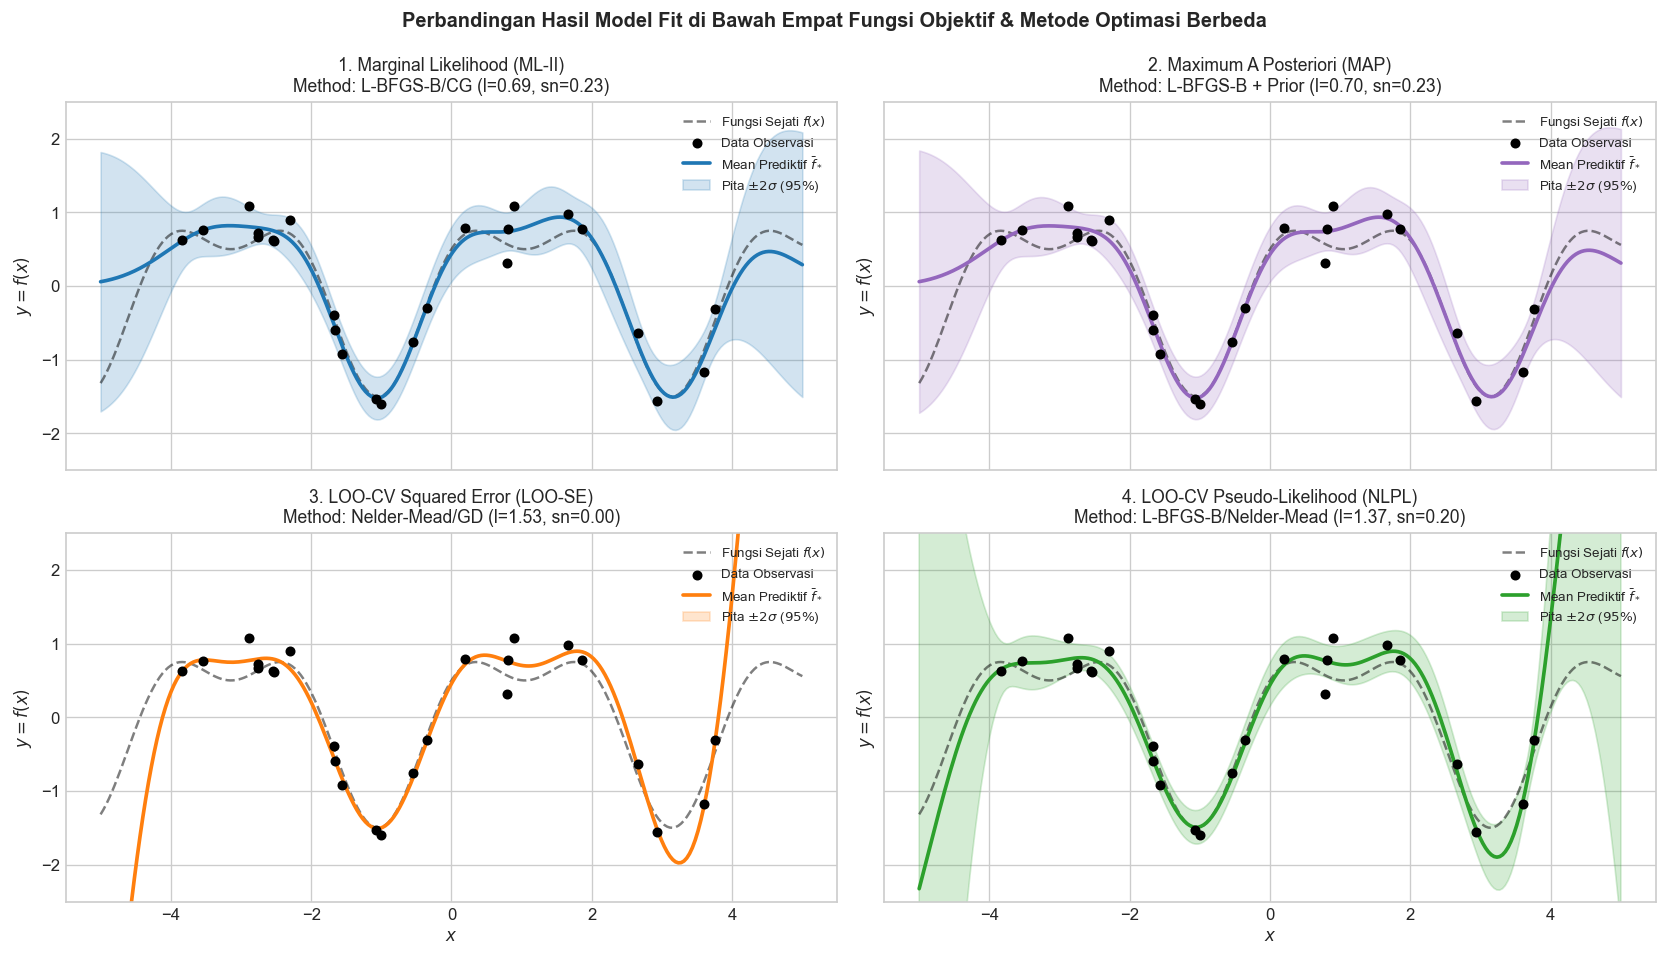

In [4]:
# 4. Visualisasi Komparasi Hasil Optimasi Berbagai Fungsi Objektif
res_map = minimize(map_and_grad, init_p, args=(X_train, y_train), jac=True, method='L-BFGS-B')
res_loo_se = minimize(loo_se_objective, init_p, args=(X_train, y_train), method='Nelder-Mead')
res_loo_nlpl = minimize(loo_nlpl_objective, init_p, args=(X_train, y_train), method='Nelder-Mead')

p_lml = np.exp(res_lbfgs.x)
p_map = np.exp(res_map.x)
p_se = np.exp(res_loo_se.x)
p_nlpl = np.exp(res_loo_nlpl.x)

def gp_predict(X_tr, y_tr, X_te, l, sf, sn):
    N_tr = len(y_tr)
    K_tr = se_kernel(X_tr, X_tr, l, sf) + (sn**2 + 1e-7) * np.eye(N_tr)
    K_s = se_kernel(X_tr, X_te, l, sf)
    K_ss = se_kernel(X_te, X_te, l, sf) + 1e-7 * np.eye(len(X_te))
    
    L = np.linalg.cholesky(K_tr)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_tr))
    mu = np.dot(K_s.T, alpha)
    v = np.linalg.solve(L, K_s)
    cov = K_ss - np.dot(v.T, v)
    std = np.sqrt(np.maximum(np.diag(cov), 1e-8))
    return mu, std

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

cases_to_plot = [
    {'title': f'1. Marginal Likelihood (ML-II)\nMethod: L-BFGS-B/CG (l={p_lml[0]:.2f}, sn={p_lml[2]:.2f})', 'p': p_lml, 'c': '#1f77b4', 'ax': axes[0, 0]},
    {'title': f'2. Maximum A Posteriori (MAP)\nMethod: L-BFGS-B + Prior (l={p_map[0]:.2f}, sn={p_map[2]:.2f})', 'p': p_map, 'c': '#9467bd', 'ax': axes[0, 1]},
    {'title': f'3. LOO-CV Squared Error (LOO-SE)\nMethod: Nelder-Mead/GD (l={p_se[0]:.2f}, sn={p_se[2]:.2f})', 'p': p_se, 'c': '#ff7f0e', 'ax': axes[1, 0]},
    {'title': f'4. LOO-CV Pseudo-Likelihood (NLPL)\nMethod: L-BFGS-B/Nelder-Mead (l={p_nlpl[0]:.2f}, sn={p_nlpl[2]:.2f})', 'p': p_nlpl, 'c': '#2ca02c', 'ax': axes[1, 1]}
]

for item in cases_to_plot:
    ax = item['ax']
    l, sf, sn = item['p']
    mu, std = gp_predict(X_train, y_train, X_test, l, sf, sn)
    
    ax.plot(X_test, y_true_test, 'k--', alpha=0.5, label='Fungsi Sejati $f(x)$')
    ax.scatter(X_train, y_train, c='black', s=25, zorder=5, label='Data Observasi')
    ax.plot(X_test, mu, color=item['c'], lw=2.2, label='Mean Prediktif $\\bar{f}_*$')
    ax.fill_between(X_test.ravel(), mu - 2*std, mu + 2*std, color=item['c'], alpha=0.20, label='Pita $\pm 2\sigma$ ($95\%$)')
    
    ax.set_title(item['title'], fontsize=10.5)
    ax.set_ylabel('$y = f(x)$')
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('$x$')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle("Perbandingan Hasil Model Fit di Bawah Empat Fungsi Objektif & Metode Optimasi Berbeda", y=0.99, fontsize=12, weight='bold')
plt.tight_layout()
plt.show()
